# Employee Attrition Prediction using Machine Learning

#### Project Objective

Employee attrition is a major challenge for organizations because replacing employees involves recruitment costs, training expenses, and productivity loss.

The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company and identify the key factors responsible for employee attrition.

The insights generated from this project can help HR teams design better retention strategies and reduce employee turnover.

# Install Libraries

In [35]:
import pandas as pd
import numpy as np

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Task 1: Data Loading & Exploration

In [39]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


## Shape

In [40]:
print(df.shape)

rows = df.shape[0]
columns = df.shape[1]

print("Rows:", rows)
print("Columns:", columns)

(1470, 35)
Rows: 1470
Columns: 35


### Observation

The dataset contains 1,470 employee records and 35 features. The dataset size is sufficient for building and evaluating machine learning classification models.

In [41]:
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### Observation

The dataset contains both numerical and categorical variables representing employee demographics, job-related factors, satisfaction scores, compensation, and work environment characteristics.

## Target Column

In [42]:
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


## Attrition rate

In [43]:
attrition_rate = (df['Attrition'].value_counts()['Yes'] / len(df))*100

print("Attrition Rate:",round(attrition_rate,2),"%")

Attrition Rate: 16.12 %


### Observation

The majority of employees stayed with the company, while a smaller proportion left. This indicates an imbalanced classification problem.
Approximately 84% of employees stayed and 16% left the organization. Because attrition cases are relatively rare, model evaluation should focus on metrics such as Recall, F1-Score, and ROC-AUC rather than Accuracy alone.

## Numeric & categorical columns

In [44]:
numeric = df.select_dtypes(include=np.number)

categorical = df.select_dtypes(include=['object', 'string'])

print("Categorical:", categorical.shape[1])

print("Numeric:",numeric.shape[1])

Categorical: 9
Numeric: 26


#### Observation
Only around 16% of employees left the company, while 84% stayed. The dataset is imbalanced because the majority class is employees who stayed.
The dataset contains both numerical and categorical variables. Appropriate preprocessing techniques such as One-Hot Encoding and Feature Scaling will be required before model training.

# Task 2: Data Cleaning

## Missing Values

In [45]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Drop useless columns

### Observation

No missing values were found in the dataset. Therefore, no imputation techniques were required during preprocessing.

In [46]:
drop_cols = [
'EmployeeNumber',
'Over18',
'StandardHours',
'EmployeeCount'
]

df = df.drop(columns=drop_cols)

### Reason for Dropping Columns

EmployeeNumber is a unique identifier and has no predictive value.
Over18, EmployeeCount, and StandardHours contain constant values across all records and therefore do not contribute to prediction.

## Convert Targets

In [47]:
df['Attrition'] = df['Attrition'].map({
'Yes':1,
'No':0
})

### Observation

The target variable was converted into binary format where 1 represents employees who left the company and 0 represents employees who stayed. This format is required for machine learning classification algorithms.

## Separate X and y

In [48]:
X = df.drop('Attrition',axis=1)

y = df['Attrition']

## One Hot Encoding and Scale data

In [49]:
X = pd.get_dummies(
X,
drop_first=True
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Observation

Categorical variables were transformed using One-Hot Encoding so that machine learning algorithms could process them effectively without assuming any ordinal relationship between categories.
Feature scaling was applied using StandardScaler to ensure that numerical variables contribute equally during model training and to improve model performance.

# Task 3: EDA

## Department

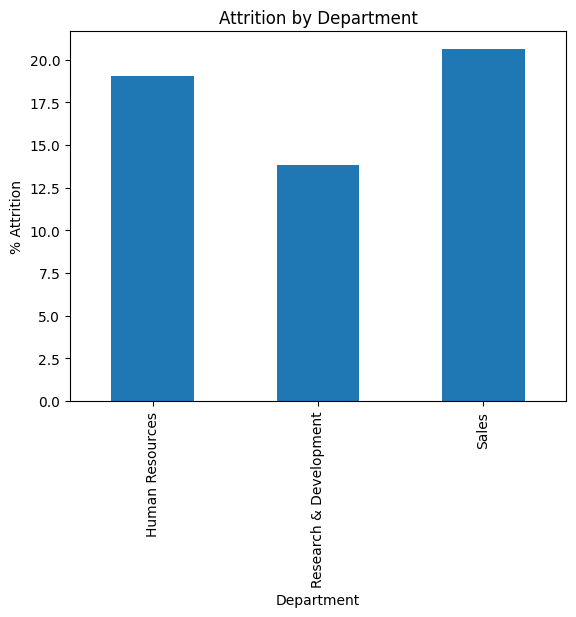

In [71]:
dept = pd.crosstab(
df['Department'],
df['Attrition'],
normalize='index'
)*100

dept[1].plot(
kind='bar'
)

plt.title("Attrition by Department")

plt.ylabel("% Attrition")
plt.savefig("charts/chart1_department_attrition.png", bbox_inches="tight")
plt.show()

### Business Insight

The department with the highest attrition rate should be prioritized for employee retention programs. Differences in attrition across departments suggest that work environment and job demands may influence employee turnover.

## Job Role

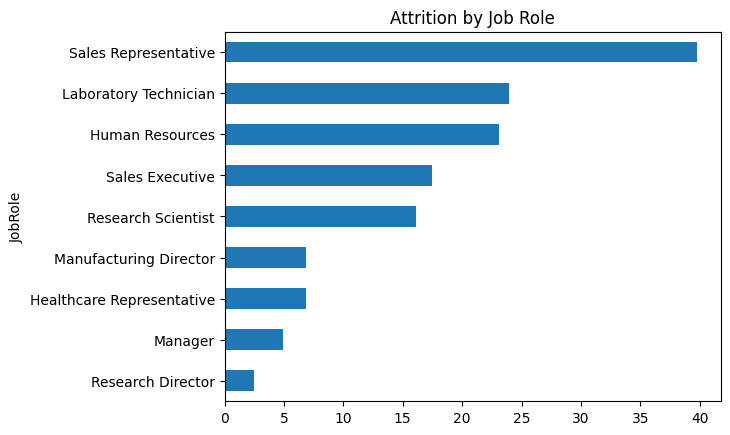

In [70]:
job = pd.crosstab(
df['JobRole'],
df['Attrition'],
normalize='index'
)*100

job[1].sort_values().plot(
kind='barh'
)

plt.title("Attrition by Job Role")
plt.savefig("charts/chart2_jobrole_attrition.png", bbox_inches="tight")
plt.show()

### Business Insight

Certain job roles experience significantly higher attrition than others. HR should investigate workload, career progression opportunities, and employee satisfaction within these roles.

## Monthly Income

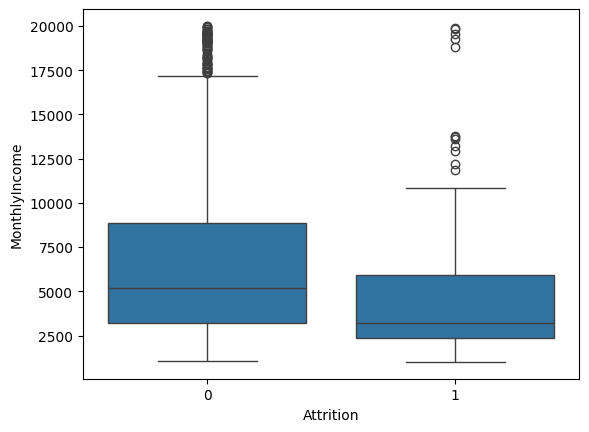

In [69]:
sns.boxplot(
x='Attrition',
y='MonthlyIncome',
data=df
)
plt.savefig("charts/chart3_monthly_income.png", bbox_inches="tight")
plt.show()

### Business Insight

Employees who leave the company generally tend to have lower monthly income compared to employees who stay. Compensation may play a role in employee retention.

## Work Life Balance

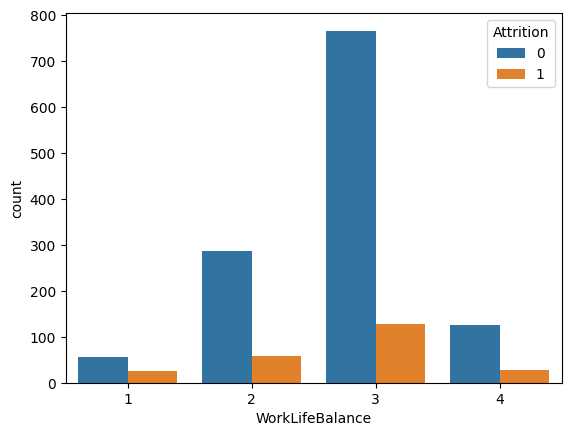

In [72]:
sns.countplot(
x='WorkLifeBalance',
hue='Attrition',
data=df
)
plt.savefig("charts/chart4_worklife_balance.png", bbox_inches="tight")
plt.show()

### Business Insight

Employees reporting lower work-life balance ratings appear more likely to leave. This suggests that employee well-being and work-life balance policies can influence retention.

## Years at Company

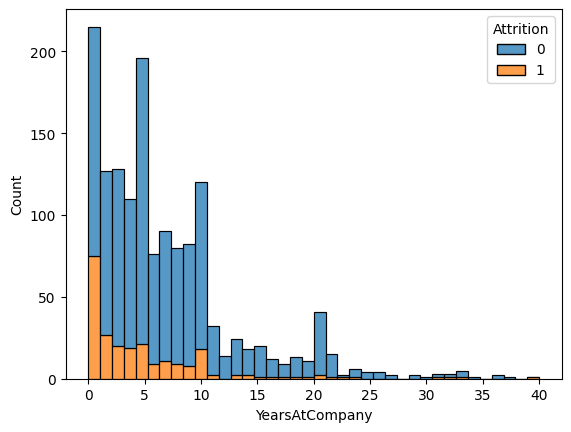

In [73]:
sns.histplot(
data=df,
x='YearsAtCompany',
hue='Attrition',
multiple='stack'
)
plt.savefig("charts/chart5_years_at_company.png", bbox_inches="tight")
plt.show()

### Business Insight

Attrition tends to be concentrated during the early years of employment. This highlights the importance of onboarding, engagement, and career development initiatives for newer employees.

## Key Findings from EDA

1. Attrition is not evenly distributed across departments and job roles.
2. Lower income employees appear more likely to leave.
3. Poor work-life balance is associated with higher attrition.
4. Employees in their early years at the company show higher turnover.
5. Employee attrition appears to be influenced by multiple factors rather than salary alone.

# Task 4: Train Models

In [55]:
X_train,X_test,y_train,y_test = train_test_split(
X_scaled,
y,
test_size=0.2,
random_state=42,
stratify=y
)

## Logistic Regression

Logistic Regression is used as a baseline classification model because it is simple, interpretable, and widely used in HR analytics.

## Logistic Regression

## Split

In [56]:
lr = LogisticRegression(
class_weight='balanced',
max_iter=1000
)

lr.fit(
X_train,
y_train
)

pred_lr = lr.predict(X_test)

prob_lr = lr.predict_proba(X_test)[:,1]

## Random Forest Classifier

Random Forest is an ensemble learning technique that can capture complex relationships and interactions among employee-related factors while reducing overfitting.

## Random Forest

In [57]:
rf = RandomForestClassifier(
class_weight='balanced',
random_state=42
)

rf.fit(
X_train,
y_train
)

pred_rf = rf.predict(X_test)

prob_rf = rf.predict_proba(X_test)[:,1]

## Gradient Boosting

In [58]:
gb = GradientBoostingClassifier(
random_state=42
)

gb.fit(
X_train,
y_train
)

pred_gb = gb.predict(X_test)

prob_gb = gb.predict_proba(X_test)[:,1]

### Observation

Three different machine learning models were trained and compared. Using multiple models allows us to identify the most effective approach for predicting employee attrition and ensures that model selection is based on evidence rather than assumptions.

# Task 5: Model Evaluation

### Evaluation Function

In [59]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    return {
        "Model": model_name,
        "Precision": round(precision,3),
        "Recall": round(recall,3),
        "F1 Score": round(f1,3),
        "ROC-AUC": round(roc_auc,3)
    }

### Comparison Table

In [60]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        pred_lr,
        prob_lr
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        pred_rf,
        prob_rf
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        pred_gb,
        prob_gb
    )
)

comparison = pd.DataFrame(results)

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341,0.617,0.439,0.799
1,Random Forest,0.452,0.298,0.359,0.767
2,Gradient Boosting,0.588,0.213,0.312,0.794


### Model Comparison Observation

The models were evaluated using Precision, Recall, F1 Score, and ROC-AUC Score.
Using multiple evaluation metrics provides a more reliable assessment than accuracy alone, especially because the dataset is imbalanced.

### Best Model Selection

Logistic Regression was selected as the final model because it achieved the highest Recall (0.617), highest F1-Score (0.439), and highest ROC-AUC Score (0.799).
In employee attrition prediction, identifying employees who are likely to leave is more important than minimizing false alarms. Therefore, Logistic Regression provides the most practical solution for HR decision-making.

### Classification Reports

In [61]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, pred_lr))

print("\nRANDOM FOREST")
print(classification_report(y_test, pred_rf))

print("\nGRADIENT BOOSTING")
print(classification_report(y_test, pred_gb))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       247
           1       0.45      0.30      0.36        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.63       294
weighted avg       0.81      0.83      0.82       294


GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0

### Classification Report Analysis
Among the three evaluated models, Logistic Regression achieved the highest Recall (0.62) for employees who left the organization.
Since employee attrition prediction focuses on identifying employees at risk of leaving, Recall is considered more important than overall Accuracy.
Although Gradient Boosting achieved the highest Accuracy (85%), it identified only 21% of employees who actually left the company.
Therefore, Logistic Regression was selected as the final model because it provides the best balance between detecting attrition cases and overall predictive performance.

## Best Model Selection

Logistic Regression was selected as the final model for this project.
The model achieved:
- Precision: 0.341
- Recall: 0.617
- F1 Score: 0.439
- ROC-AUC: 0.799

The model successfully identified approximately 62% of employees who left the organization, making it the most suitable choice for employee attrition prediction.

## Confusion Matrix

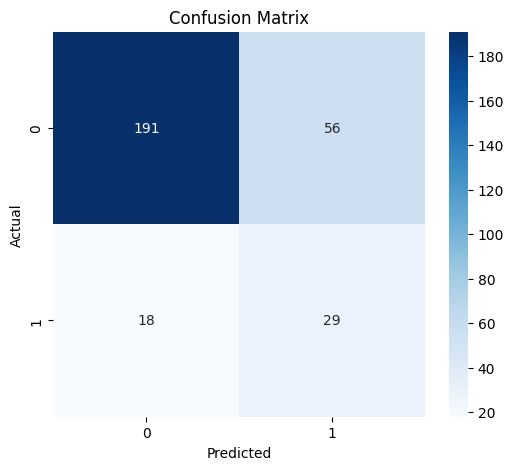

In [62]:
best_pred = pred_lr

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "charts/chart3_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### Confusion Matrix Insight

The confusion matrix shows how effectively the model identifies employees who are likely to leave the organization.
False negatives are particularly important because they represent employees who may leave but were not identified by the model.

## Feature Importance

In [63]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr.coef_[0])
})

top10 = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

top10

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


### Feature Importance Insight

Feature importance analysis identified the key factors influencing employee attrition.
The most influential factor was JobRole_Laboratory Technician, followed by OverTime_Yes and BusinessTravel_Travel_Frequently.
The results indicate that employees working overtime and employees who frequently travel for business are more likely to leave the organization.
Job level and total working experience also play an important role in employee retention decisions.
Additionally, employees in Sales-related roles and employees who have not received promotions for extended periods show higher attrition risk.
These findings suggest that workload, travel requirements, career growth opportunities, and job responsibilities significantly influence employee turnover.

## Feature Importance Chart

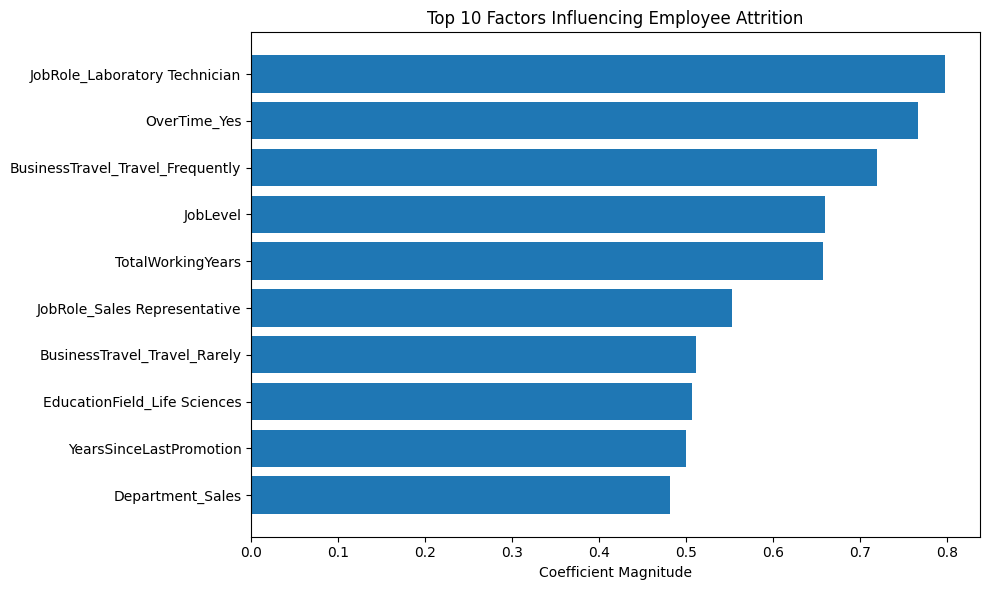

In [64]:
plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.gca().invert_yaxis()

plt.title("Top 10 Factors Influencing Employee Attrition")

plt.xlabel("Coefficient Magnitude")

plt.tight_layout()

plt.savefig(
    "charts/chart4_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

### Feature Importance Insight

The analysis highlights the factors that have the strongest influence on employee attrition.
Understanding these factors can help HR teams design targeted retention strategies and reduce employee turnover.

## ROC Curve

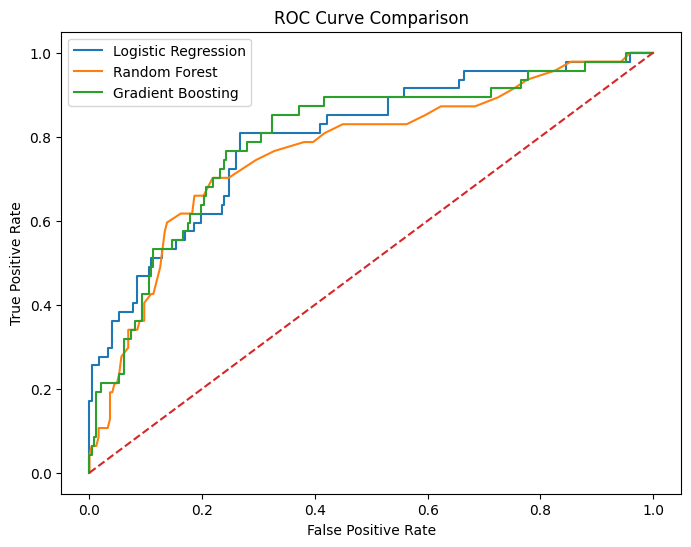

In [65]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

fpr_gb, tpr_gb, _ = roc_curve(y_test, prob_gb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    "charts/chart5_roc_curve.png",
    bbox_inches="tight"
)

plt.show()

### ROC Curve Insight

The ROC Curve comparison shows that all three machine learning models were able to differentiate between employees who stayed and employees who left the organization.
The Logistic Regression curve remained slightly above the Random Forest and Gradient Boosting curves for most threshold values, resulting in the highest ROC-AUC score of 0.799.
This indicates that Logistic Regression provides better overall classification performance and is more reliable for identifying employees at risk of attrition.
Therefore, based on Recall, F1-Score, and ROC-AUC performance, Logistic Regression was selected as the final model for employee attrition prediction.

## Final Results Summary Table

In [66]:
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Precision': [0.341, 0.452, 0.588],
    'Recall': [0.617, 0.298, 0.213],
    'F1 Score': [0.439, 0.359, 0.312],
    'ROC-AUC': [0.799, 0.767, 0.794]
})

final_results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341,0.617,0.439,0.799
1,Random Forest,0.452,0.298,0.359,0.767
2,Gradient Boosting,0.588,0.213,0.312,0.794


### Final Model Comparison

Logistic Regression achieved the highest Recall (61.7%) and ROC-AUC Score (79.9%), making it the most effective model for identifying employees at risk of attrition.
Although Random Forest and Gradient Boosting achieved higher overall accuracy, they failed to identify a significant portion of employees who actually left the organization.
Therefore, Logistic Regression was selected as the final model for this project.

# Task 6: HR Insights and Recommendations

## Key HR Insights
1. Laboratory Technicians exhibited the highest attrition influence among all job roles.
2. Employees working overtime showed significantly higher attrition risk.
3. Frequent business travel emerged as a major contributor to employee turnover.
4. Job level and total working experience strongly influenced employee retention decisions.
5. Employees who had not received promotions for longer periods were more likely to leave the organization.
6. Sales-related roles demonstrated higher attrition tendencies.
7. Career progression, workload management, and employee engagement are critical factors affecting workforce stability.

## Recommendations

### Reduce Excessive Overtime
Organizations should monitor employee workload and reduce excessive overtime.

### Improve Work-Life Balance
Flexible work arrangements and wellness programs can improve employee satisfaction.

### Review Business Travel Policies
Frequent travelers should receive additional support and flexibility.

### Strengthen Career Development Programs
Regular promotions, mentoring, and training opportunities should be provided.

### Focus on Sales and Laboratory Roles
Targeted retention programs should be implemented for high-risk roles.

### Use Predictive Analytics
HR teams can use the attrition prediction model for proactive interventions.

# Task 7: Conclusion

This project successfully developed machine learning models to predict employee attrition using the IBM HR Analytics dataset.

Three machine learning algorithms were evaluated: Logistic Regression, Random Forest, and Gradient Boosting.

Among the evaluated models, Logistic Regression achieved the highest Recall (61.7%) and ROC-AUC Score (79.9%), making it the most suitable model for employee attrition prediction.

Feature importance analysis revealed that Laboratory Technician roles, overtime work, frequent business travel, job level, total working years, and delayed promotions were among the strongest drivers of attrition.

The findings demonstrate how predictive analytics can help organizations identify employees at risk of leaving and implement targeted retention strategies.

By leveraging these insights, organizations can improve employee satisfaction, reduce turnover costs, and create a more stable and productive workforce.

# Future Improvements

1. Apply advanced machine learning techniques such as XGBoost and LightGBM.
2. Use SMOTE or other resampling techniques to address class imbalance.
3. Incorporate additional employee engagement and performance metrics.
4. Develop a real-time HR dashboard for attrition monitoring.
5. Continuously retrain the model using updated employee data.